In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
from sklearn import datasets

wine = datasets.load_wine()
wine.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [17]:
wine.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [18]:
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [19]:
wine_Df = pd.DataFrame(data= np.c_[wine['data'], wine['target']],
                      columns= wine['feature_names'] + ['class'])

# wine_Df['class'] = wine_Df['class'].map({
#     0.0: 'class_0',
#     1.0: 'class_1',
#     2.0: 'class_2'
# })

wine_Df.columns = wine_Df.columns.str.replace(' ', '')

print(wine_Df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  class  
0           

In [20]:
wine_Df["class"].value_counts()

,count
class,
1.0,71
0.0,59
2.0,48


In [21]:
wine_Df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  class

In [22]:
print(wine_Df.describe())

          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.572359   
min         0.9

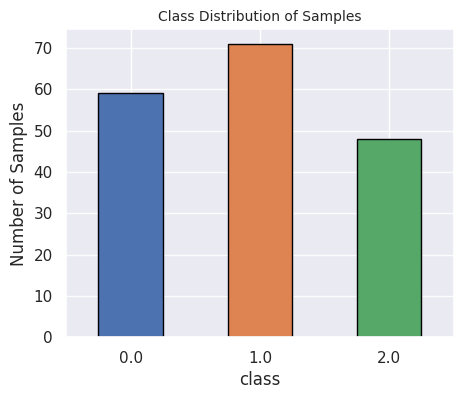

In [23]:
##Show the number of samples in each class by a bar graph
from matplotlib import pyplot as plt
import seaborn as sns

# Set seaborn style with light background
sns.set_style(style='darkgrid', rc={'axes.facecolor': '.8', 'grid.color': '.6'})
sns.set_palette(palette='deep')
# Using the font_scale parameter
sns.set(font_scale=1.0)
# Choose an attractive color palette
colors = sns.color_palette(palette='deep')

plt.figure(figsize=(5, 4))   # width = 5 inches, height = 4 inches
# Plot
wine_Df.groupby('class').size().plot(
                kind='bar',
                color=colors,
                edgecolor='black')

#Add plot title and labels
plt.title('Class Distribution of Samples', fontsize=10)
plt.ylabel('Number of Samples')
plt.xlabel('class')
plt.xticks(rotation=0)

# Grid only on Y-axis
plt.grid(axis='y', linestyle='-', alpha=0.9)

plt.show()

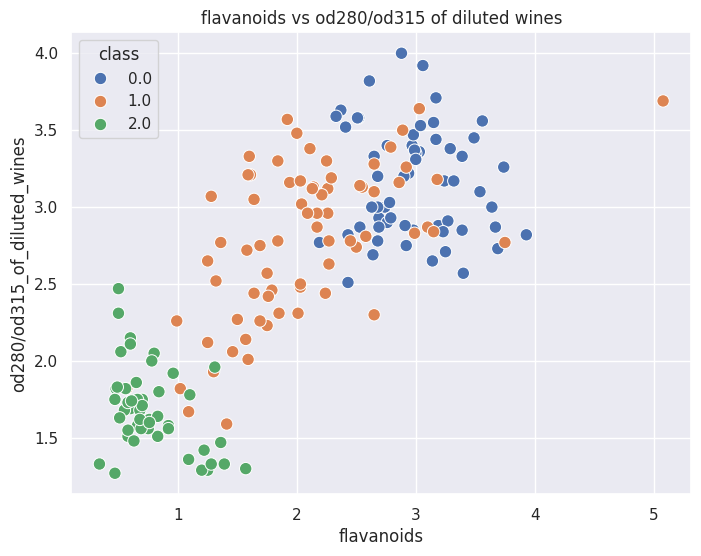

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=wine_Df,
    x="flavanoids",
    y="od280/od315_of_diluted_wines",
    hue="class",
    palette="deep",
    s=80
)

plt.title("flavanoids vs od280/od315 of diluted wines")
plt.show()